# Funnel Analysis & Monthly Charges Deep Dive

## Objective
Understand where customers drop off in their lifecycle
and how pricing relates to churn behavior.

## Questions to Answer
- At what stage do most customers churn?
- Do higher paying customers churn more?
- What is the revenue at risk from High Risk customers?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load scored dataset from Day 3
df = pd.read_csv('../data/churn_scored.csv')

print("Data loaded:", df.shape)
print("Columns:", df.columns.tolist())

Data loaded: (7043, 15)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'tenure', 'Contract', 'InternetService', 'MonthlyCharges', 'TotalCharges', 'TechSupport', 'PaperlessBilling', 'Tenure_Cohort', 'Risk_Score', 'Risk_Segment', 'Churn', 'Churn_Binary']


In [2]:
# Customer Lifecycle Funnel
# Define funnel stages based on tenure milestones
total = len(df)
month1 = len(df[df['tenure'] >= 1])
month3 = len(df[df['tenure'] >= 3])
month6 = len(df[df['tenure'] >= 6])
month12 = len(df[df['tenure'] >= 12])
month24 = len(df[df['tenure'] >= 24])

funnel_data = {
    'Stage': ['Signed Up', 'Month 1+', 'Month 3+', 'Month 6+', 'Month 12+', 'Month 24+'],
    'Customers': [total, month1, month3, month6, month12, month24]
}

funnel_df = pd.DataFrame(funnel_data)
funnel_df['Drop_Off'] = funnel_df['Customers'].shift(1) - funnel_df['Customers']
funnel_df['Drop_Off_Pct'] = (funnel_df['Drop_Off'] / funnel_df['Customers'].shift(1) * 100).round(1)
funnel_df['Retention_Pct'] = (funnel_df['Customers'] / total * 100).round(1)

print("=== Customer Lifecycle Funnel ===")
print(funnel_df.to_string(index=False))

=== Customer Lifecycle Funnel ===
    Stage  Customers  Drop_Off  Drop_Off_Pct  Retention_Pct
Signed Up       7043       NaN           NaN          100.0
 Month 1+       7032      11.0           0.2           99.8
 Month 3+       6181     851.0          12.1           87.8
 Month 6+       5672     509.0           8.2           80.5
Month 12+       4974     698.0          12.3           70.6
Month 24+       3927    1047.0          21.0           55.8


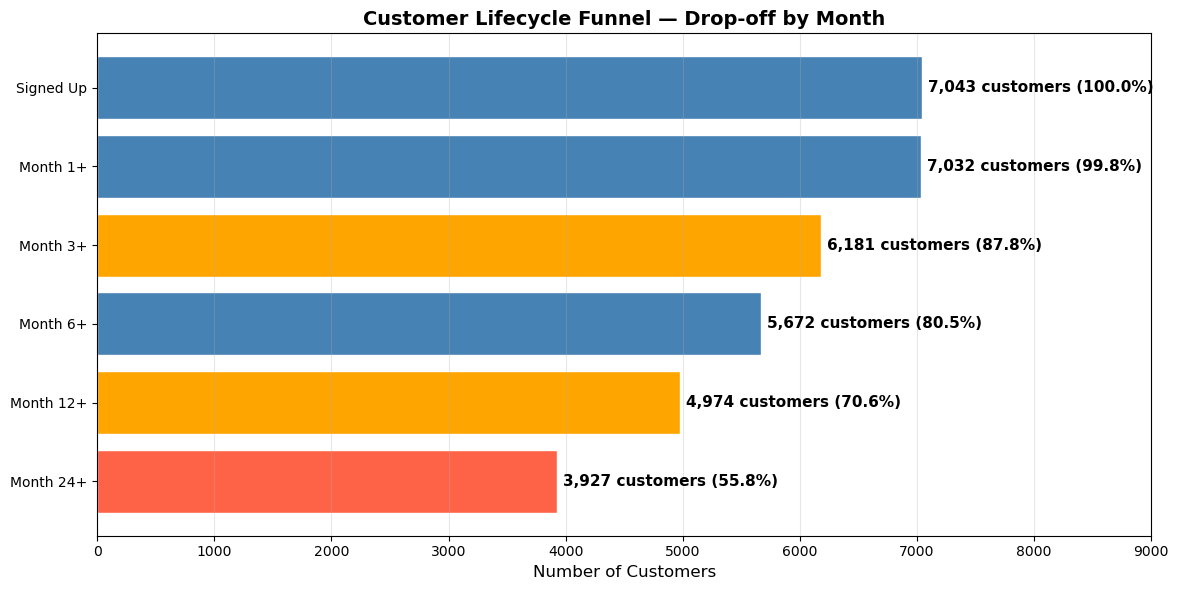

In [3]:
# Visualize the funnel
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['steelblue', 'steelblue', 'orange', 'steelblue', 'orange', 'tomato']

bars = ax.barh(funnel_df['Stage'], funnel_df['Customers'], color=colors, edgecolor='white')

# Add labels
for bar, customers, ret_pct in zip(bars, funnel_df['Customers'], funnel_df['Retention_Pct']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{customers:,} customers ({ret_pct}%)',
            va='center', fontsize=11, fontweight='bold')

ax.set_title('Customer Lifecycle Funnel — Drop-off by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Customers', fontsize=12)
ax.set_xlim(0, 9000)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

=== Avg Monthly Charges: Churned vs Stayed ===
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


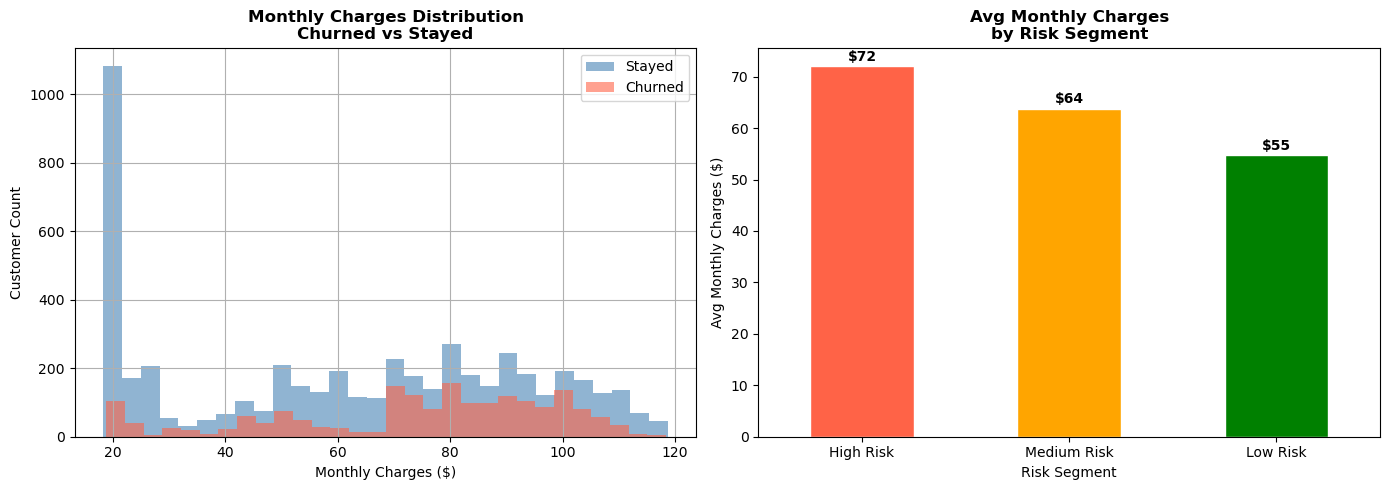

In [4]:
# Monthly Charges vs Churn
print("=== Avg Monthly Charges: Churned vs Stayed ===")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

# Distribution of monthly charges by churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Distribution
df[df['Churn']=='No']['MonthlyCharges'].hist(bins=30, alpha=0.6, 
    color='steelblue', label='Stayed', ax=axes[0])
df[df['Churn']=='Yes']['MonthlyCharges'].hist(bins=30, alpha=0.6, 
    color='tomato', label='Churned', ax=axes[0])
axes[0].set_title('Monthly Charges Distribution\nChurned vs Stayed', fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Customer Count')
axes[0].legend()

# Chart 2 — Avg charges by Risk Segment
risk_charges = df.groupby('Risk_Segment')['MonthlyCharges'].mean().reindex(
    ['High Risk', 'Medium Risk', 'Low Risk'])
colors = ['tomato', 'orange', 'green']
risk_charges.plot(kind='bar', color=colors, ax=axes[1], edgecolor='white')
axes[1].set_title('Avg Monthly Charges\nby Risk Segment', fontweight='bold')
axes[1].set_xlabel('Risk Segment')
axes[1].set_ylabel('Avg Monthly Charges ($)')
axes[1].tick_params(axis='x', rotation=0)

for bar, val in zip(axes[1].patches, risk_charges):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'${val:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# Revenue at Risk Analysis
revenue_at_risk = df.groupby('Risk_Segment').agg(
    Customer_Count=('customerID', 'count'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean'),
    Total_Monthly_Revenue=('MonthlyCharges', 'sum'),
    Actual_Churn_Rate=('Churn_Binary', 'mean')
).round(2)

revenue_at_risk = revenue_at_risk.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
revenue_at_risk['Revenue_At_Risk'] = (
    revenue_at_risk['Total_Monthly_Revenue'] * 
    revenue_at_risk['Actual_Churn_Rate']
).round(2)

print("=== Monthly Revenue at Risk by Segment ===")
print(revenue_at_risk.to_string())

print(f"\n💰 Total monthly revenue at risk from High Risk segment:")
print(f"${revenue_at_risk.loc['High Risk', 'Revenue_At_Risk']:,.0f}/month")
print(f"${revenue_at_risk.loc['High Risk', 'Revenue_At_Risk']*12:,.0f}/year")

=== Monthly Revenue at Risk by Segment ===
              Customer_Count  Avg_Monthly_Charges  Total_Monthly_Revenue  Actual_Churn_Rate  Revenue_At_Risk
Risk_Segment                                                                                                
High Risk               3132                72.02              225562.00               0.49        110525.38
Medium Risk             1828                63.78              116592.65               0.15         17488.90
Low Risk                2083                54.71              113961.95               0.03          3418.86

💰 Total monthly revenue at risk from High Risk segment:
$110,525/month
$1,326,305/year


## Key Finding #6 — Revenue at Risk

| Segment | Customers | Avg Monthly $ | Churn Rate | Monthly Revenue at Risk |
|---|---|---|---|---|
| High Risk | 3,132 | $72 | 49% | $110,525 |
| Medium Risk | 1,828 | $64 | 15% | $17,489 |
| Low Risk | 2,083 | $55 | 3% | $3,419 |

**💰 $1,326,305 in annual revenue at risk from High Risk segment alone**

**Key Insight:**
- Churned customers pay $74/month vs $61 for loyal customers
- Higher charges correlate with higher churn — pricing perception issue
- High Risk customers generate $225K/month but 49% will leave

**Business Recommendation:**
- A retention program costing even $200K/year that saves 20% of 
  High Risk customers would recover $265K — ROI positive
- Consider loyalty pricing for month-to-month customers at Month 6